In [1]:
import pandas as pd
import anndata as ad
import os
import scanpy as sc
from utils import *
from matplotlib_venn import venn3, venn2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
from gtfparse import read_gtf
import gseapy as gp
import decoupler as dc
from utils import *
from first_part import *

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packag

In [4]:
adata_tr = ad.read_h5ad("/Volumes/U32 Shadow/data/ATAC-seq/PPMI/PPMI_RNAseq_IR3_Analysis/adata_transcript.h5ad")
adata_tr.obs.groupby(['COHORT_DEFINITION', "subgroup"])['PATNO'].nunique()
condition = "subgroup"
method = 'pydeseq2_sex_adjusted_no_refit_bulk_rna'
adata_tr.obs.reset_index(drop=True, inplace=True)
adata_pd = adata_tr[adata_tr.obs['COHORT_DEFINITION'] =="Parkinson's Disease", :]
adata_pd.obs.reset_index(drop=True, inplace=True)
adata_pd.obs["celltype"] = "Bulk"
adata_pd.obs["brain_region"] = "blood"
adata_pd.obs["PatientID"] = adata_pd.obs["PATNO"].tolist()
adata_pd = adata_pd[adata_pd.obs["subgroup"].isin(["GBA1","LRRK2","SPOR"])]
adata_pd.obs["group"] = adata_pd.obs[condition].values
adata_pd.obs["condition"] = adata_pd.obs[condition].values
adata_pd.var["peakid"] = adata_pd.var_names
adata_pd
adata_pd.obs.groupby(['COHORT_DEFINITION', "subgroup"])['PATNO'].nunique()


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  new_obj.index = new_index
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17325/3544661037.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pd.obs["group"] = adata_pd.obs[condition].values


COHORT_DEFINITION    subgroup
Parkinson's Disease  GBA1         44
                     LRRK2       121
                     SPOR        207
Name: PATNO, dtype: int64

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17325/1094734898.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pd_bl.obs["Sex"] = adata_pd_bl.obs["SEX"].replace({0:"Female", 1:"Male"})


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1_Female vs. LRRK2_Female: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.963e-01 U_stat=1.754e+03
LRRK2_Female vs. SPOR_Female: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.243e-09 U_stat=2.456e+04
GBA1_Male vs. LRRK2_Male: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:9.279e-01 U_stat=1.901e+03
LRRK2_Male vs. SPOR_Male: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.121e-01 U_stat=2.995e+04
GBA1_Female vs. SPOR_Female: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.182e-01 U_stat=3.648e+03
GBA1_Male vs. SPOR_Male: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.655e-01 U_stat=8.918e+03
p-valu

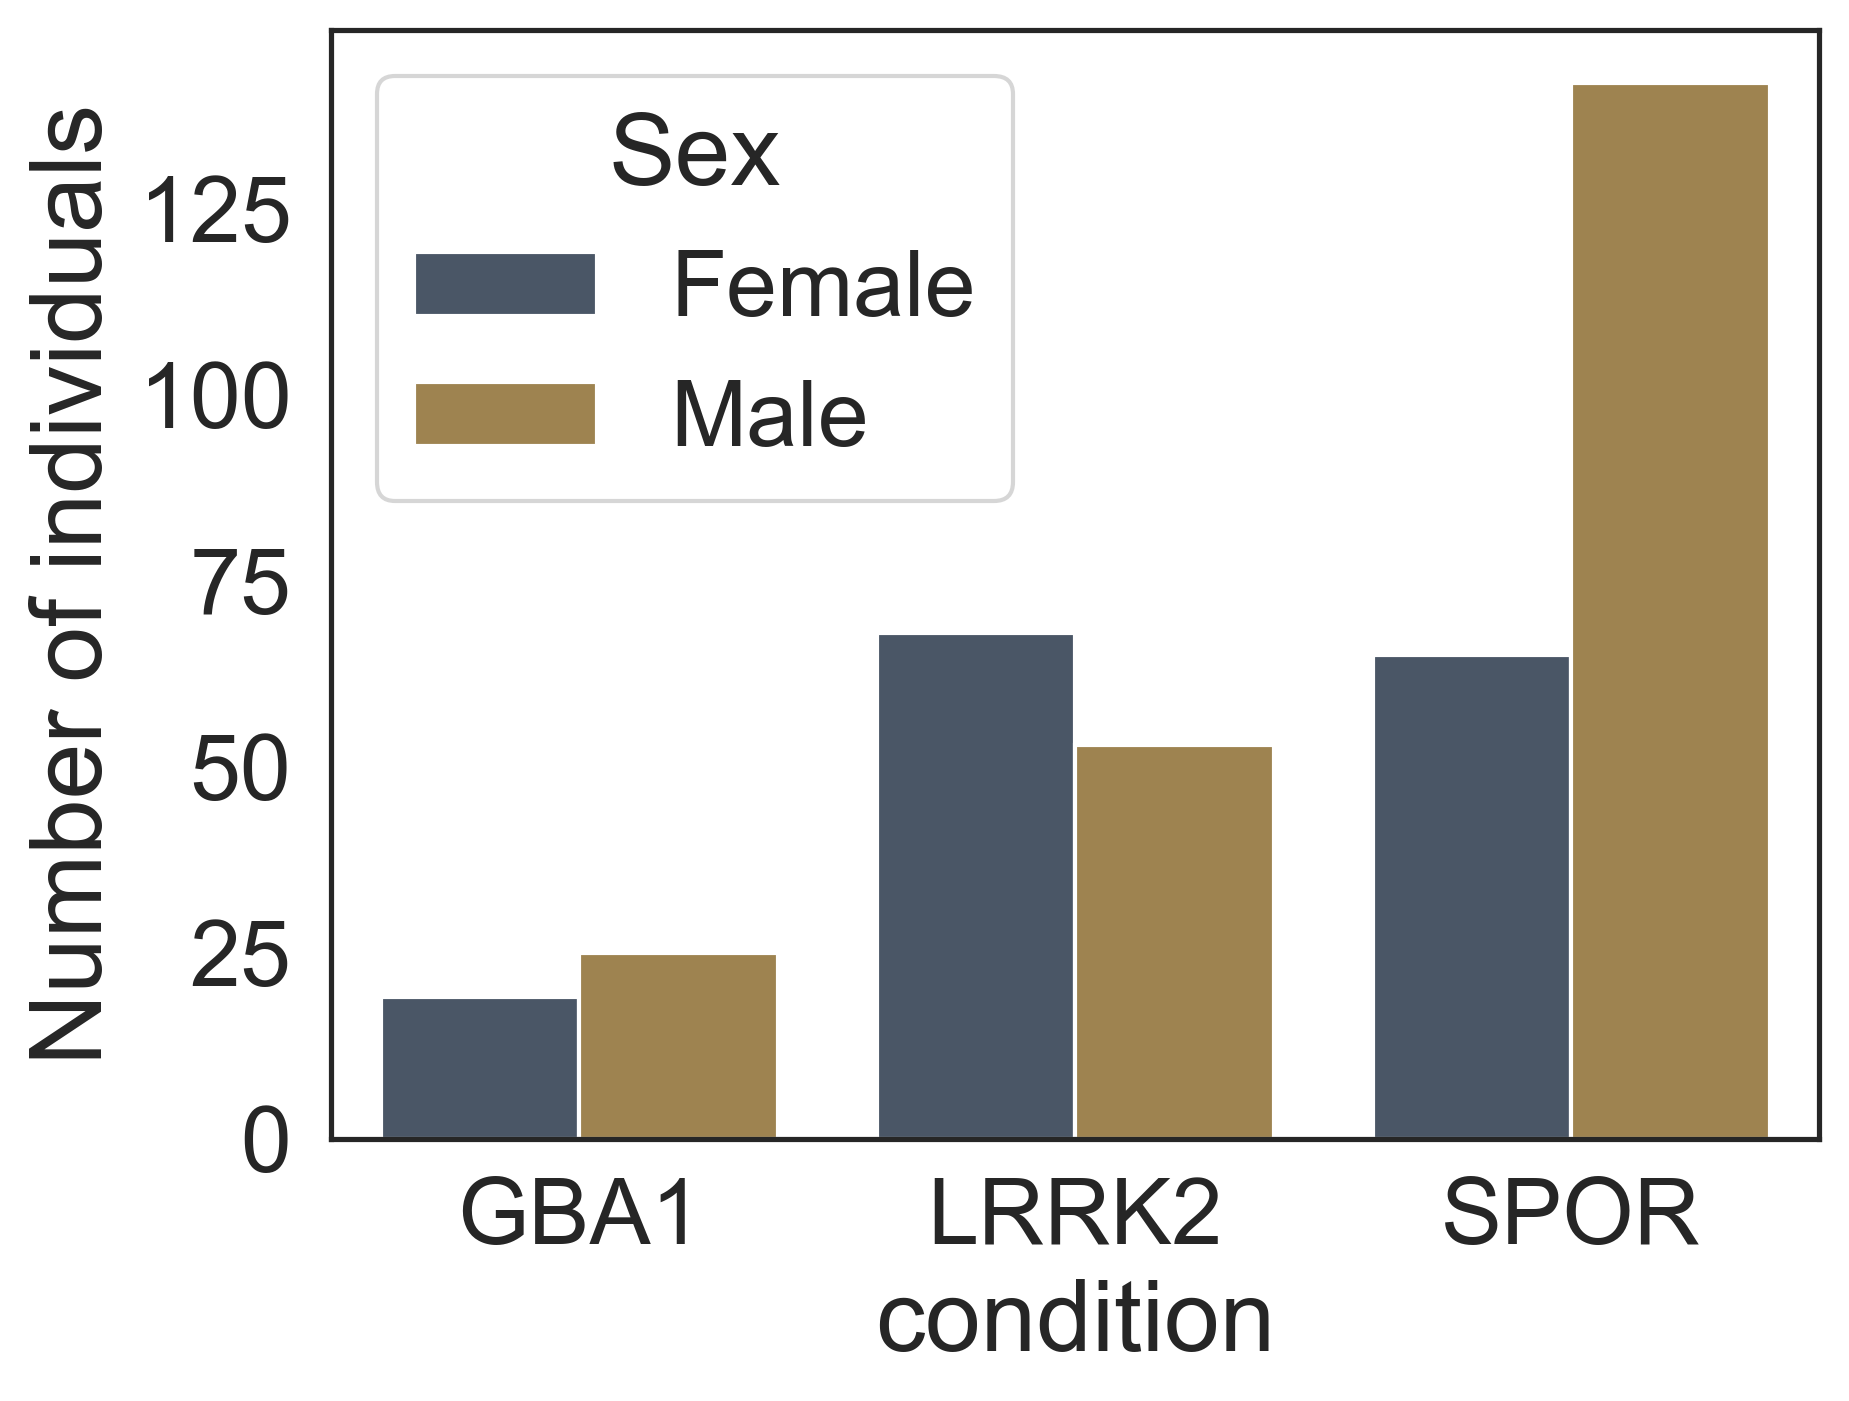

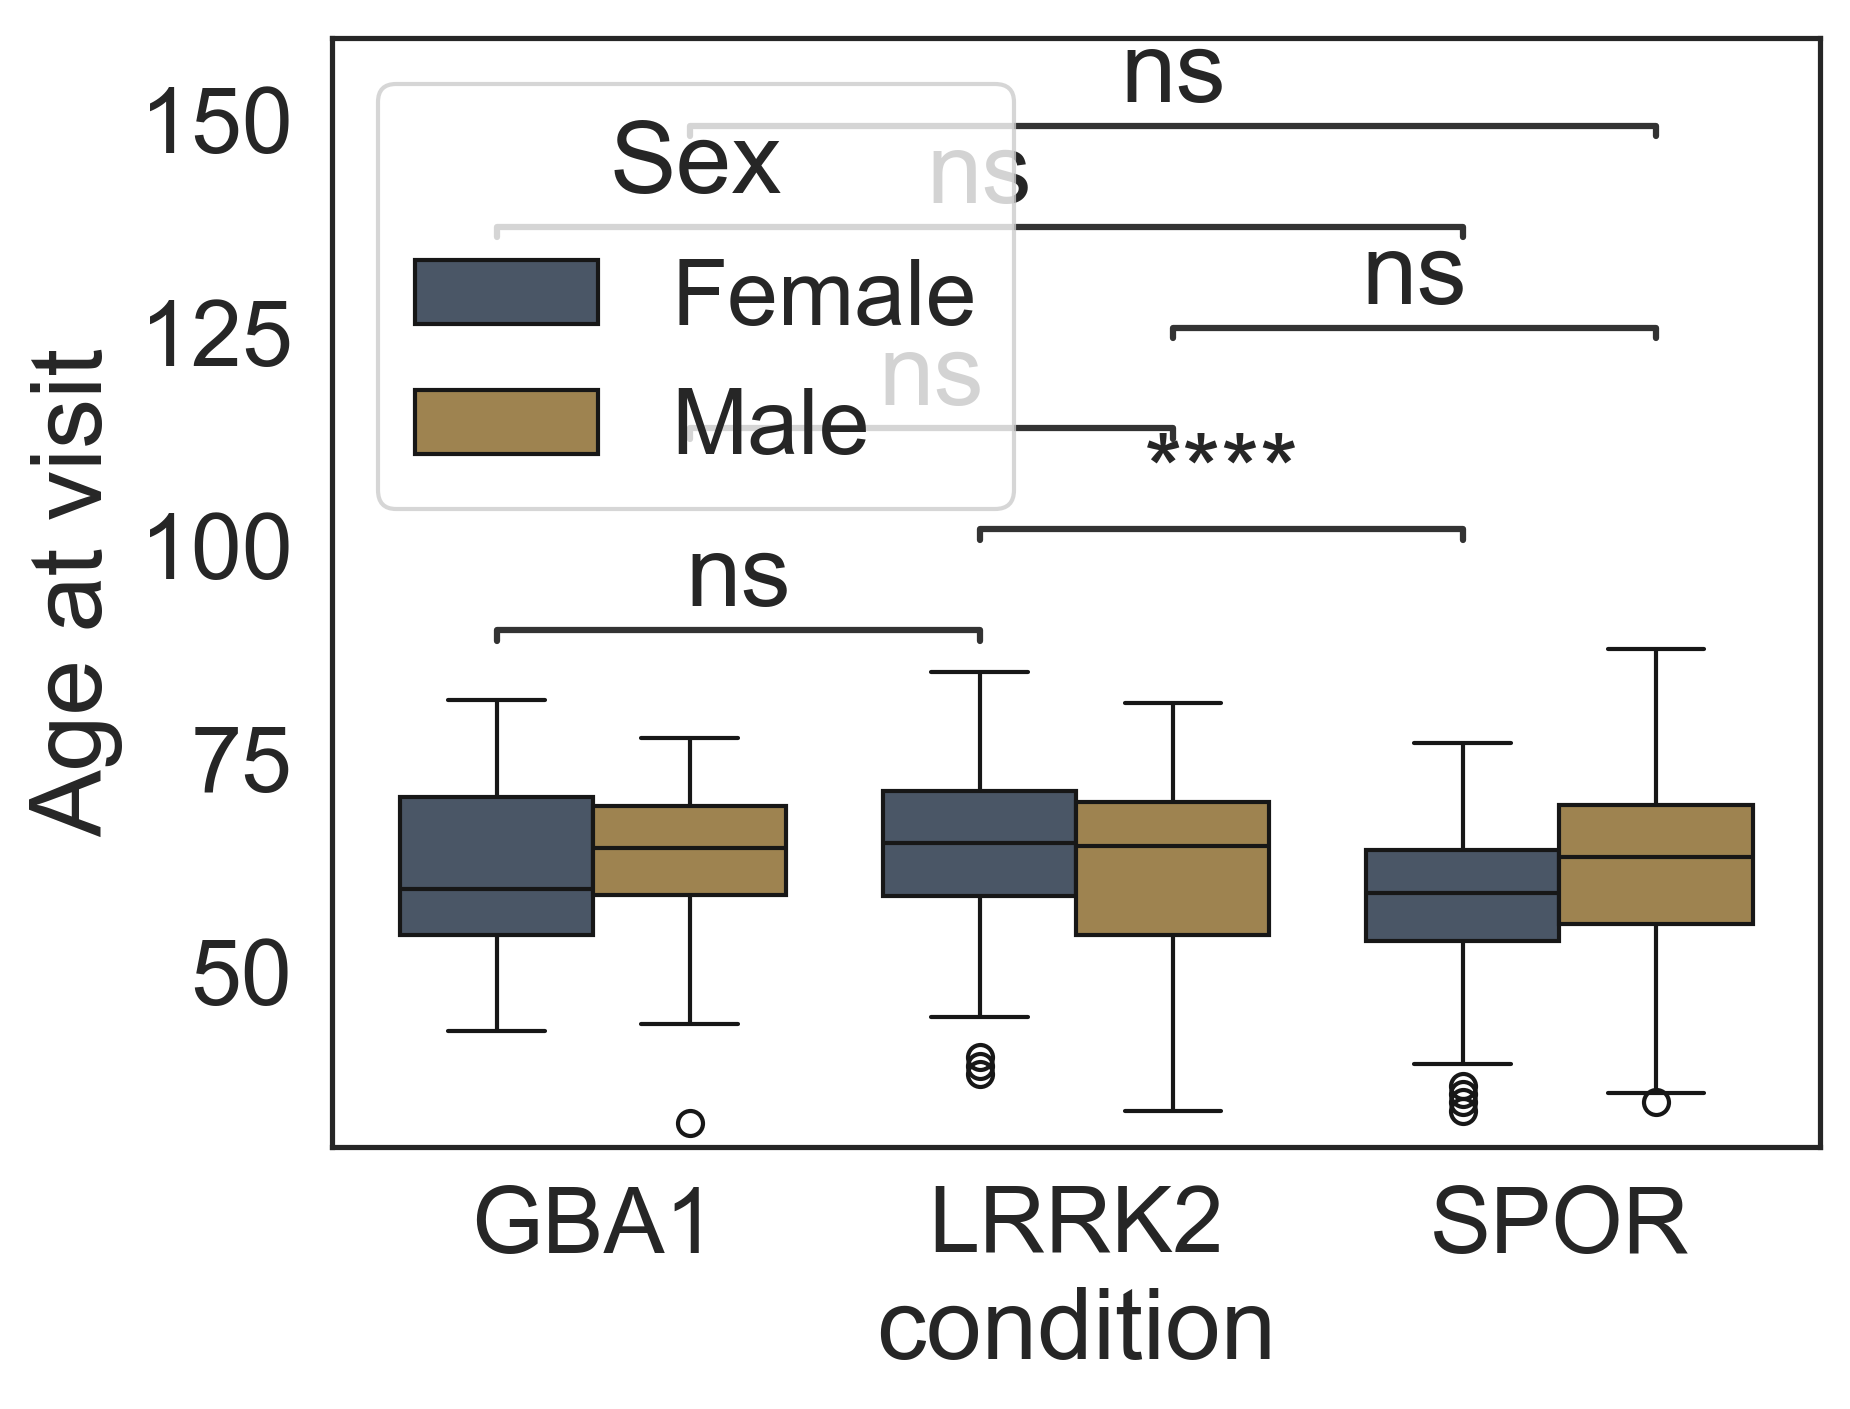

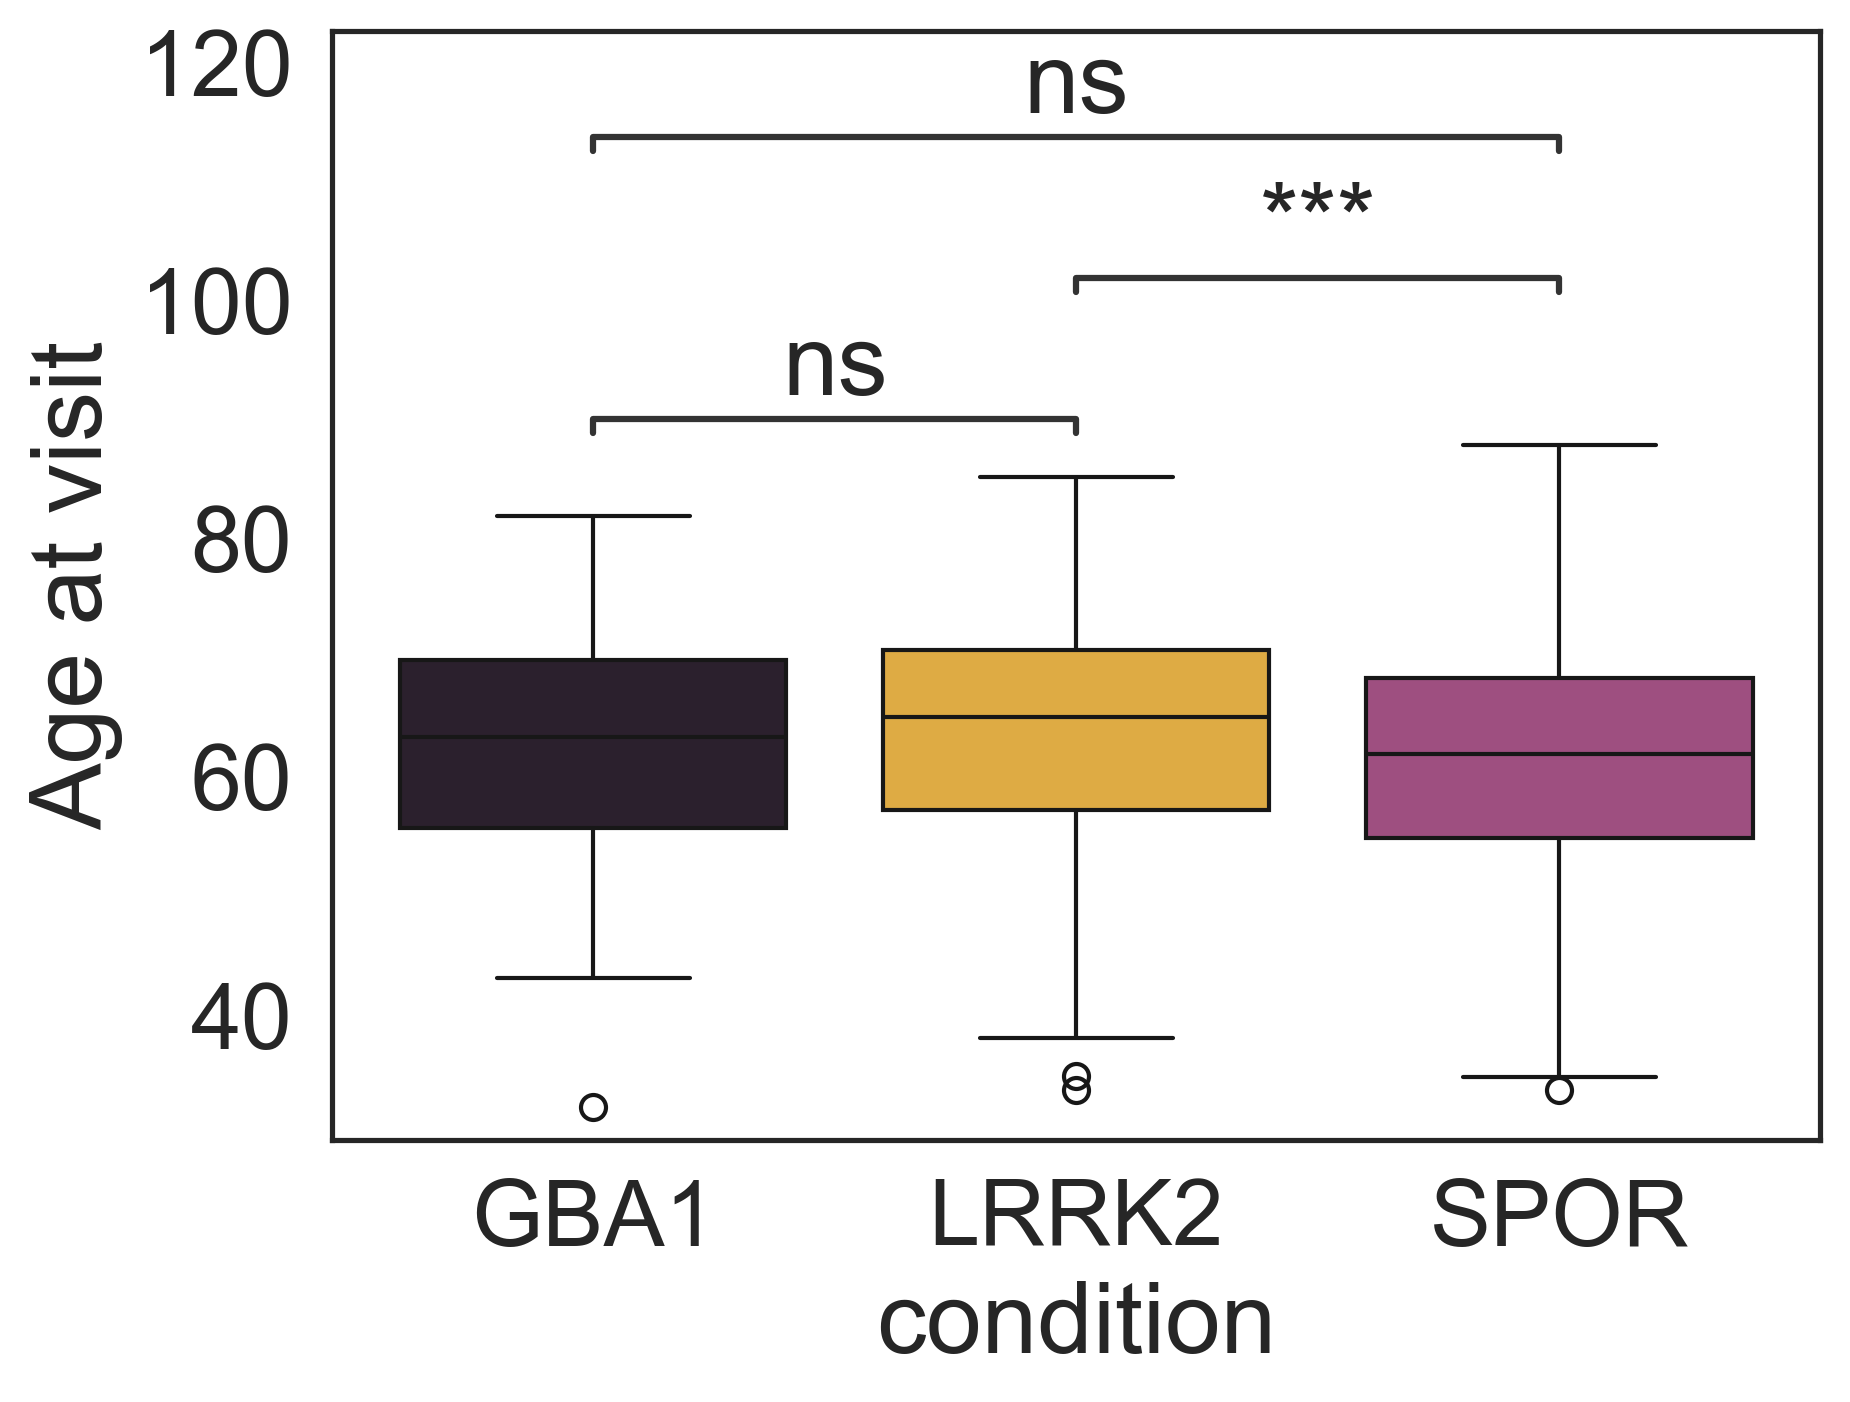

In [48]:
#KEEP all measurements for all individuals
tokeep = adata_pd.obs.sort_values("EVENT_ID").index#.drop_duplicates("PATNO", keep="first").index
adata_pd_unique = adata_pd[tokeep]
adata_pd_unique
adata_pd_bl = adata_pd_unique#[adata_pd.obs["EVENT_ID"]=="BL"]
adata_pd_bl.obs["Sex"] = adata_pd_bl.obs["SEX"].replace({0:"Female", 1:"Male"})
adata_pd_bl.obs["Age at visit"] = adata_pd_bl.obs["AGE_AT_VISIT"].tolist()
sns.set(style="white", font_scale=2)

fig, ax = plt.subplots()
toplot = adata_pd_bl.obs.groupby(["condition","Sex"]).PATNO.nunique().reset_index()
sns.barplot(data=toplot, ax=ax,x="condition", y="PATNO", hue="Sex", palette=COLORS_CT)
ax.set_ylabel("Number of individuals")
plt.savefig("./figures/barplot_blood_transcripts__sex.svg")



fig, ax = plt.subplots()
sns.boxplot(data=adata_pd_bl.obs, ax=ax,x="condition", y="Age at visit", hue="Sex", palette=COLORS_CT)
pairs=[(("GBA1", "Female"),("SPOR","Female")),(("LRRK2","Female"),("GBA1", "Female")),
           (("LRRK2","Female"),("SPOR","Female")),
      (("GBA1", "Male"),("SPOR","Male")),(("LRRK2","Male"),("GBA1", "Male")),
           (("LRRK2","Male"),("SPOR","Male"))
      ]
annotator= Annotator(pairs=pairs,ax=ax,data=adata_pd_bl.obs,x="condition", y="Age at visit", hue="Sex",
                         order=['GBA1','LRRK2','SPOR'])
                         # order=['CTRL','GBA1','LRRK2','SPOR'])
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Benjamini-Hochberg')
annotator.apply_and_annotate()
plt.savefig("./figures/barplot_blood_transcripts_age_at_visit_between_condition_strat_sex.svg")
fig, ax = plt.subplots()
sns.boxplot(data=adata_pd_bl.obs, ax=ax,x="condition", y="Age at visit", #hue="Sex", 
                    palette=COLORS_CT)
pairs=[(("GBA1", "Female"),("SPOR","Female")),(("LRRK2","Female"),("GBA1", "Female")),
           (("LRRK2","Female"),("SPOR","Female")),
      (("GBA1", "Male"),("SPOR","Male")),(("LRRK2","Male"),("GBA1", "Male")),
           (("LRRK2","Male"),("SPOR","Male"))
      ]
pairs=[("GBA1","SPOR"),("LRRK2", "GBA1"),
           ("LRRK2","SPOR")]
annotator= Annotator(pairs=pairs,ax=ax,data=adata_pd_bl.obs,x="condition", y="Age at visit", #hue="Sex",
                         order=['GBA1','LRRK2','SPOR'])
                         # order=['CTRL','GBA1','LRRK2','SPOR'])
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Benjamini-Hochberg')
annotator.apply_and_annotate()
plt.savefig("./figures/barplot_blood_transcripts_age_at_visit_between_condition.svg")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1 vs. LRRK2: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.799e-01 U_stat=8.758e+03
LRRK2 vs. SPOR: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.793e-86 U_stat=1.817e+05
GBA1 vs. SPOR: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.660e-26 U_stat=4.095e+04


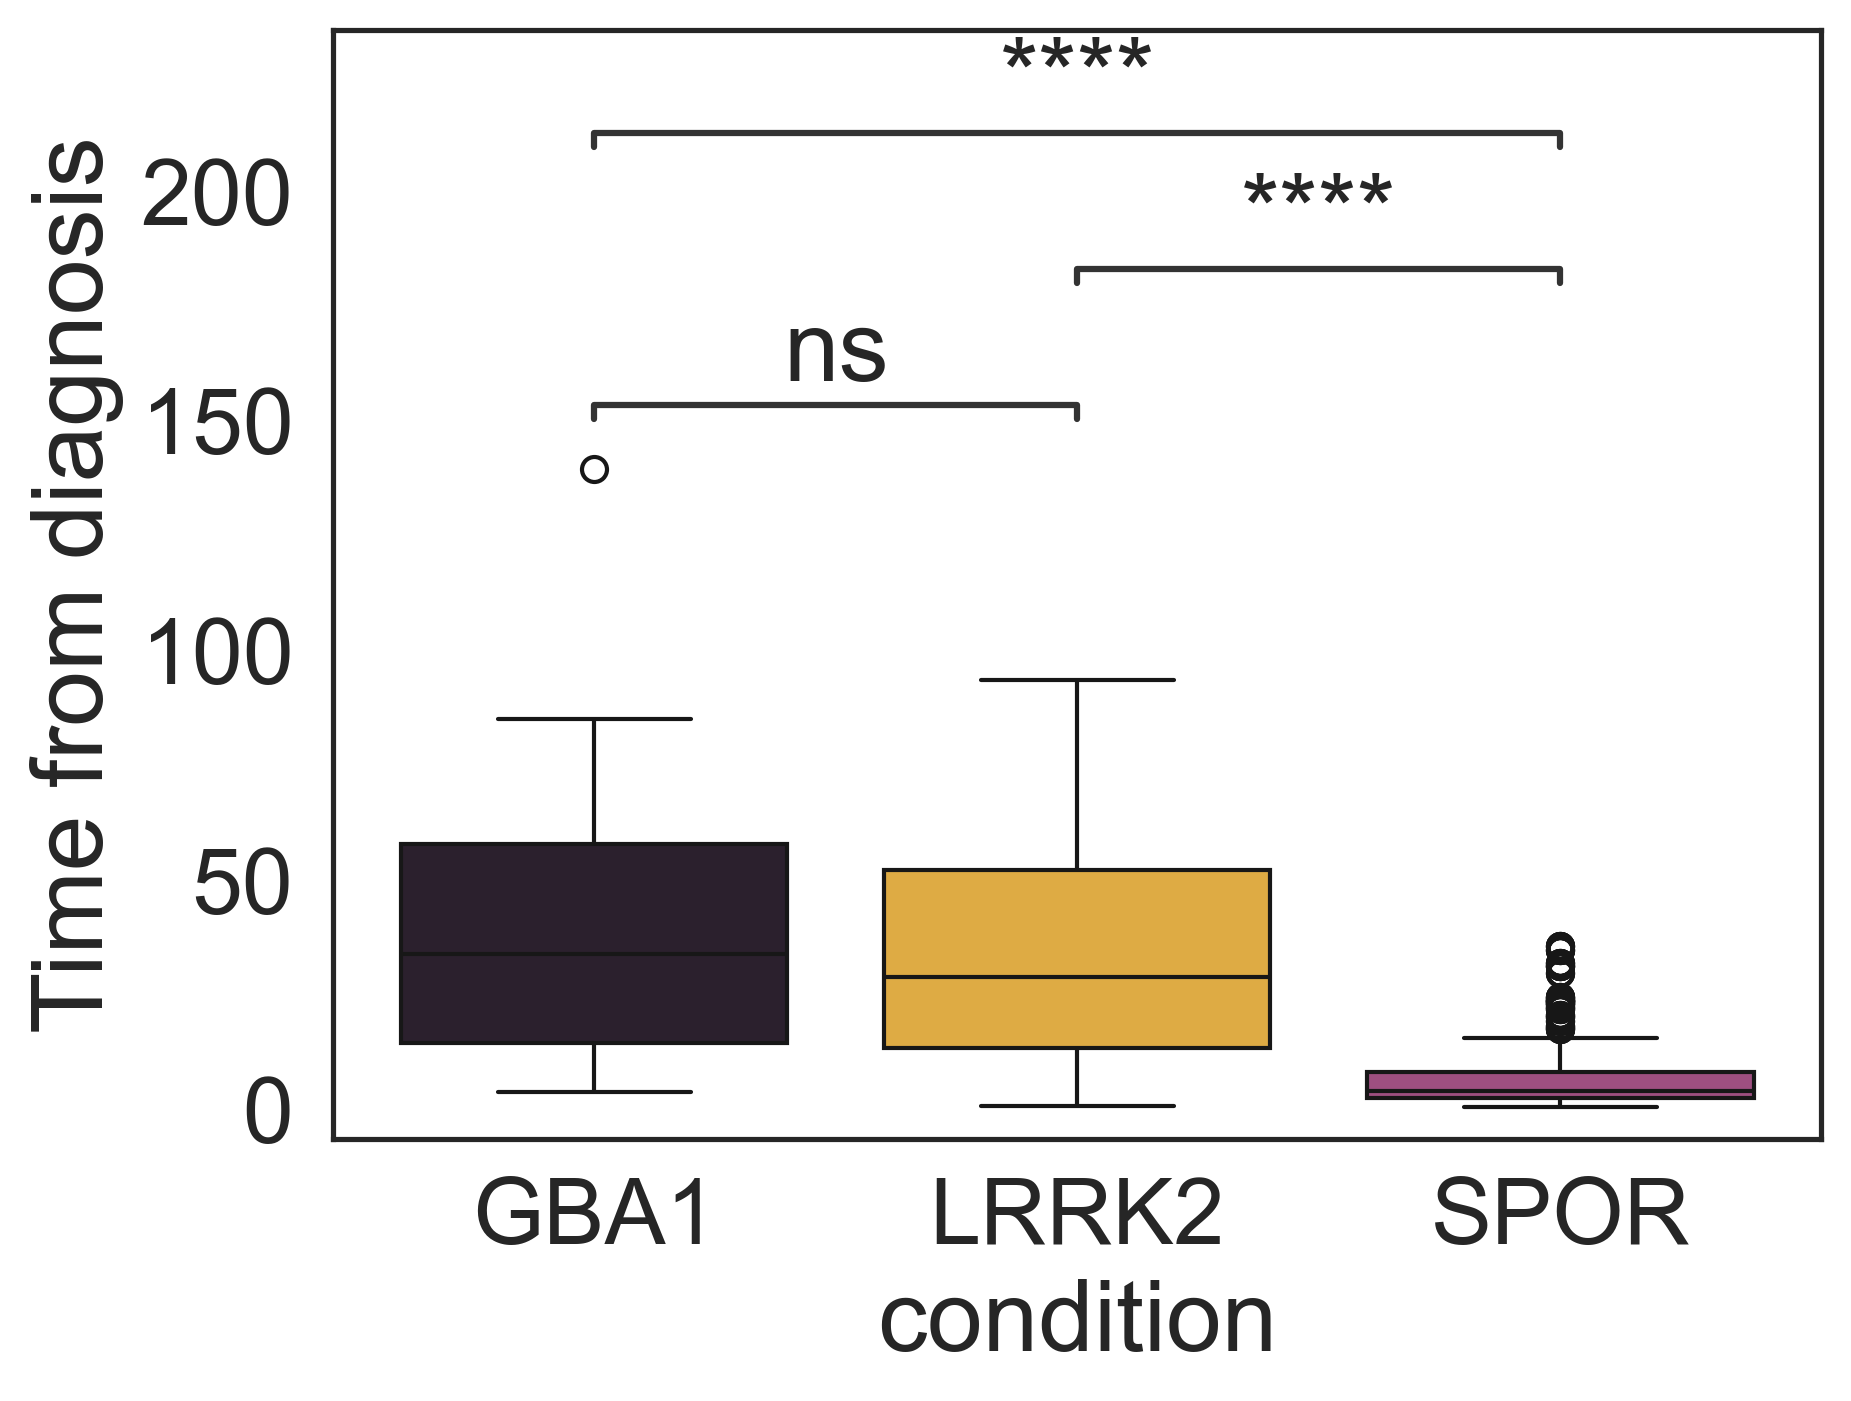

In [43]:
fig, ax = plt.subplots()
adata_pd_bl.obs["Time from diagnosis"] = adata_pd_bl.obs["duration"].tolist()
sns.boxplot(ax=ax, data=adata_pd_bl.obs, x="condition", y="Time from diagnosis", hue="condition", palette=COLORS_CT)#, hue="Sex", palette=COLORS_CT)
pairs=[(("GBA1", "GBA1"),("SPOR","SPOR")),(("LRRK2","LRRK2"),("GBA1", "GBA1")),
           (("LRRK2","LRRK2"),("SPOR","SPOR"))]
pairs=[("GBA1","SPOR"),("LRRK2", "GBA1"),
           ("LRRK2","SPOR")]

annotator= Annotator(pairs=pairs,ax=ax,data=adata_pd_bl.obs,x='condition',y="Time from diagnosis", hue="condition",
                         order=['GBA1','LRRK2','SPOR'])
                         # order=['CTRL','GBA1','LRRK2','SPOR'])
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Benjamini-Hochberg')
annotator.apply_and_annotate()
plt.savefig("./figures/barplot_blood_transcripts_duration_between_condition.svg")

In [7]:
peaks_df = differential_expression(adata_pd_bl, 0, method, corr_=["SEX"], columns="group_separate", refit=True)
peaks_df
peaks_df.to_pickle("./res_DE_blood_transcripts_bulk_all_separate_sex_adjusted.pickle")

ok
blood_Bulk
blood_Bulk DE analysis
SPOR$GBA1
group
GBA1     60
SPOR    749
dtype: int64


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  new_obj.index = new_index
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


(809, 203048)


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
Fitting size factors...
... done in 3.09 seconds.

Fitting dispersions...
... done in 48.61 seconds.

Fitting dispersion trend curve...
... done in 3.04 seconds.

Fitting MAP dispersions...
... done in 43.95 seconds.

Fitting LFCs...
... done in 64.70 seconds.

Calculating cook's distance...
... done in 13.48 seconds.

Replacing 47976 outlier genes.

Fitting dispersions...
... done in 10.79 seconds.

Fitting MAP dispersions...
... done in 11.23 seconds.

Fitting LFCs...
... done in 33.46 seconds.

Running Wald tests...
... done in 9.12 seconds.



Log2 fold change & Wald test p-value: group GBA1 vs SPOR
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0        65629.518922       -0.206959  0.131499 -1.573843  1.155237e-01   
2        49998.919481        0.173814  0.084824  2.049110  4.045140e-02   
3          206.999424       -0.399130  1.380387 -0.289144  7.724715e-01   
4          539.910653       -3.765055  1.958506 -1.922411  5.455402e-02   
5            5.000830       -2.045422  5.547649 -0.368701  7.123508e-01   
...               ...             ...       ...       ...           ...   
204616  199512.944874        1.579670  0.226778  6.965718  3.267342e-12   
204617   26697.582264        1.145976  0.261706  4.378865  1.192989e-05   
204618  669778.177359        0.604477  0.136222  4.437444  9.103322e-06   
204619    3739.790209       -0.218560  0.366785 -0.595879  5.512564e-01   
204620   33803.791385        0.661365  0.171393  3.858770  1.139590e-04   

                padj  
0       5.878846e-0

...

Log2 fold change & Wald test p-value: group LRRK2 vs SPOR
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0        62945.564642       -0.215053  0.067060 -3.206882  1.341823e-03   
2        51952.862256        0.180994  0.046285  3.910398  9.214410e-05   
3          195.893994       -0.365158  0.773309 -0.472202  6.367825e-01   
4          451.739194       -1.938044  1.129568 -1.715739  8.620991e-02   
5            3.722572        2.915689  3.368488  0.865578  3.867217e-01   
...               ...             ...       ...       ...           ...   
204616  198692.558483        0.850383  0.125965  6.750943  1.468872e-11   
204617   25760.816046        0.401204  0.145075  2.765490  5.683727e-03   
204618  663007.462164        0.218377  0.069548  3.139952  1.689757e-03   
204619    3763.771465       -0.096157  0.204296 -0.470676  6.378722e-01   
204620   33901.553347        0.370735  0.094224  3.934621  8.332804e-05   

                padj  
0       1.044228e-

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/generic.py:6329: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value


group
GBA1      60
LRRK2    268
dtype: int64
(328, 201555)


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
Fitting size factors...
... done in 1.09 seconds.

Fitting dispersions...
... done in 27.21 seconds.

Fitting dispersion trend curve...
... done in 2.89 seconds.

Fitting MAP dispersions...
... done in 29.61 seconds.

Fitting LFCs...
... done in 33.58 seconds.

Calculating cook's distance...
... done in 3.50 seconds.

Replacing 41701 outlier genes.

Fitting dispersions...
... done in 3.08 seconds.

Fitting MAP dispersions...
... done in 2.71 seconds.

Fitting LFCs...
... done in 10.08 seconds.

Running Wald tests...
... do

Log2 fold change & Wald test p-value: group LRRK2 vs GBA1
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0        58287.103661       -0.004973  0.123782 -0.040172  0.967956  0.999998
2        59239.586910        0.008447  0.088939  0.094981  0.924330  0.999998
3          171.194920       -0.006187  1.652860 -0.003743  0.997013  0.999998
4           96.278522        2.174316  3.749738  0.579858  0.562010  0.999998
5            1.931489        1.645232  3.784085  0.434777  0.663725  0.999998
...               ...             ...       ...       ...       ...       ...
204616  330130.773695       -0.769415  0.303721 -2.533297  0.011300  0.576871
204617   32356.374844       -0.216023  0.341141 -0.633236  0.526579  0.999998
204618  802695.132672       -0.357673  0.136255 -2.625016  0.008664  0.491612
204619    3681.726107        0.127309  0.416463  0.305690  0.759840  0.999998
204620   43012.244742       -0.284496  0.225423 -1.262055  0.206929  0.999998

[2015

['RNU1-1-201' 'COL6A3-212' 'SNORA26-201' 'SNORA38-201' 'SNORA65-201'
 'RNU6ATAC-201' 'SNORD67-201' 'RNU2-2P-201' 'RPS25-206' 'GAPDH-211'
 'RNU4-2-201' 'RNU5A-1-201' 'RPL13-207' 'SREBF1-210' 'SNORA37-201']


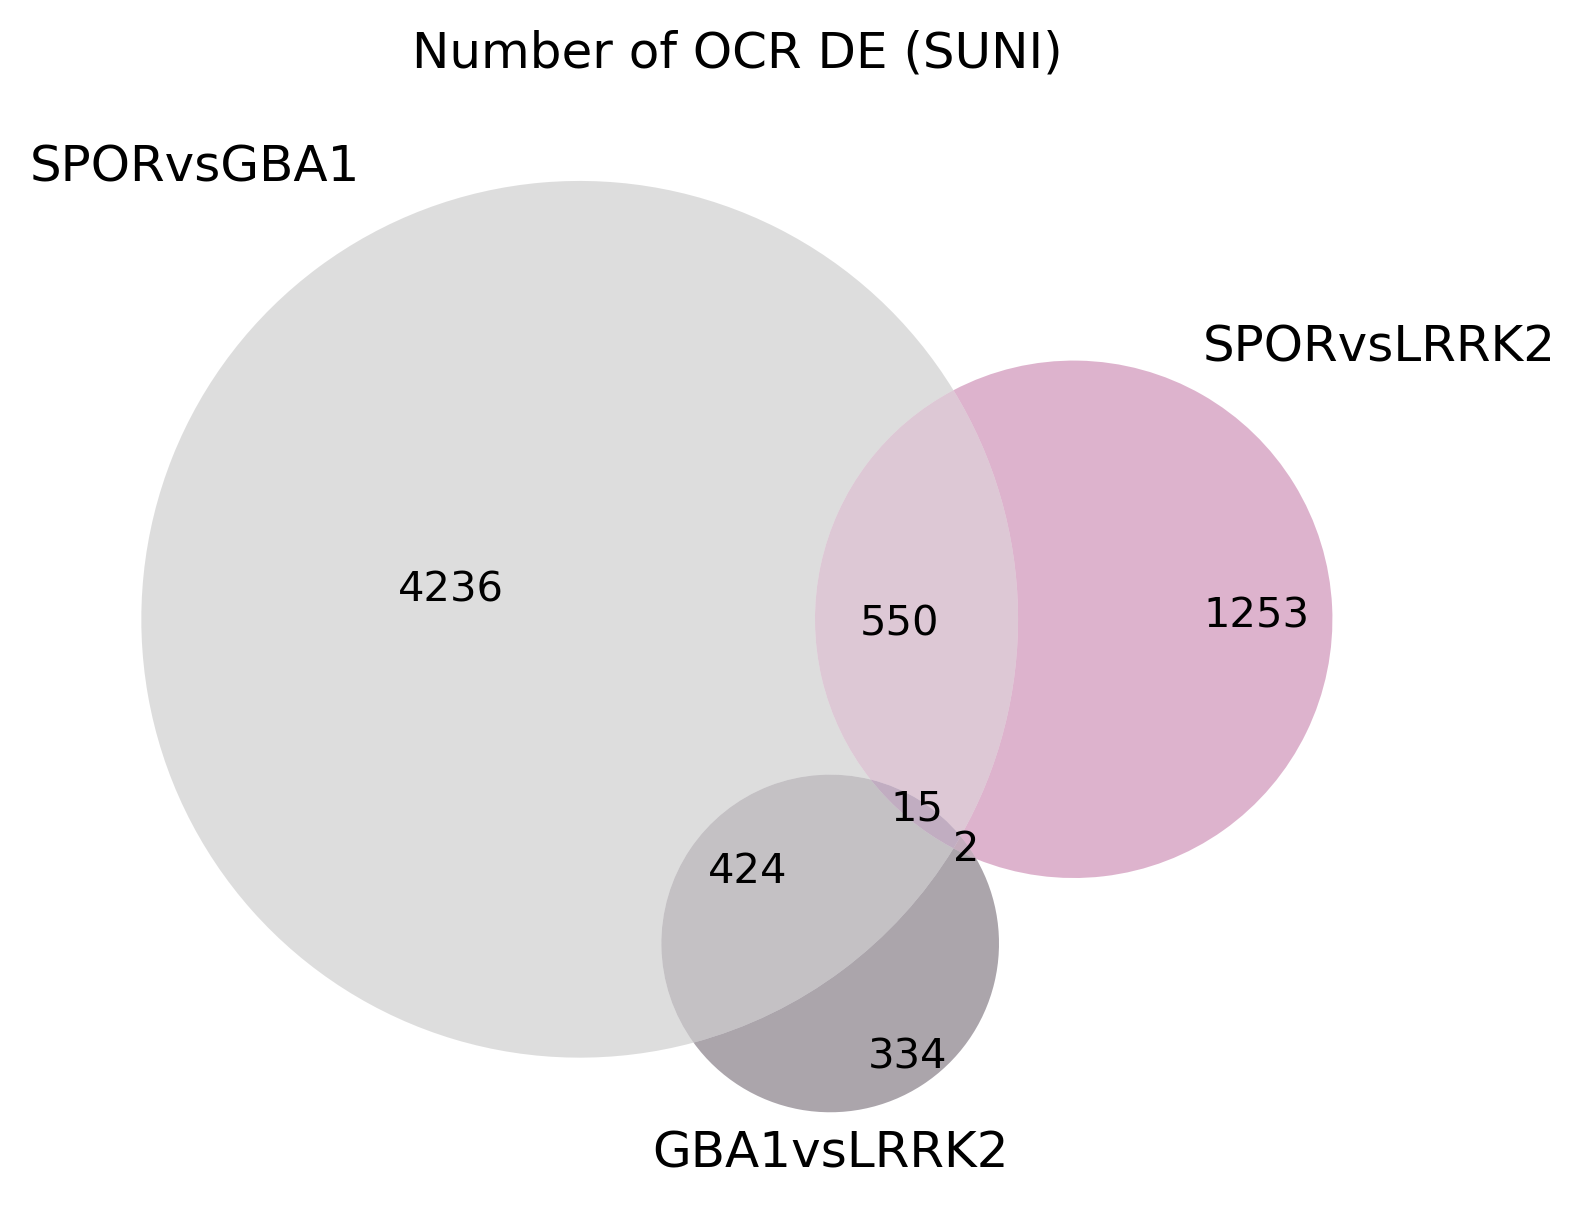

In [12]:
peaks_df = pd.read_pickle("./res_DE_blood_transcripts_bulk_all_separate_sex_adjusted.pickle")
def combine_hex_values(d):
  d_items = sorted(d.items())
  tot_weight = sum(d.values())
  red = int(sum([int(k[:2], 16)*v for k, v in d_items])/tot_weight)
  green = int(sum([int(k[2:4], 16)*v for k, v in d_items])/tot_weight)
  blue = int(sum([int(k[4:6], 16)*v for k, v in d_items])/tot_weight)
  zpad = lambda x: x if len(x)==2 else '0' + x
  return zpad(hex(red)[2:]) + zpad(hex(green)[2:]) + zpad(hex(blue)[2:])

dico_pk = {it:p for it,p in zip(peaks_df.peakid,peaks_df.gene_name)}
br="SUNI"
# ct="AST"
verse = "LRRK2"
# verse = "All"
res_DE= peaks_df
tmp = res_DE[(res_DE.padj <=0.05)&(np.abs(res_DE.log2FoldChange)>0.5)]
comp1 = tmp[tmp.comparison=="SPOR$GBA1"]
comp2= tmp[tmp.comparison=="SPOR$%s"%verse]
comp3 = tmp[tmp.comparison=="GBA1$%s"%verse]
palette={"GBA1vs%s"%verse:"#2D1E2F",  "SPORvs%s"%verse:"#AB4283","SPORvsGBA1":"#ababab"}


set1 = set(comp1.peakid.tolist())
set2=set(comp2.peakid.tolist())
set3=set(comp3.peakid.tolist())
v = venn3(subsets=[set1,set2,set3],
                 set_labels = ("SPORvsGBA1","SPORvs%s"%verse, "GBA1vs%s"%verse))
v.get_patch_by_id('100').set_color(palette["SPORvsGBA1"])
v.get_patch_by_id('100').set_edgecolor('none')
v.get_patch_by_id('010').set_color(palette["SPORvs%s"%verse])
v.get_patch_by_id('010').set_edgecolor('none')
v.get_patch_by_id('001').set_color(palette["GBA1vs%s"%verse])
v.get_patch_by_id('001').set_edgecolor('none')

v110 = combine_hex_values({"ababab": 0.5, "AB4283": 0.5})
# print(v110)
v.get_patch_by_id('110').set_color("#%s"%v110)
v.get_patch_by_id('110').set_edgecolor('none')

v101 = combine_hex_values({"ababab": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('101').set_color("#%s"%v101)
v.get_patch_by_id('101').set_edgecolor('none')

v011 = combine_hex_values({"AB4283": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('011').set_color("#%s"%v011)
v.get_patch_by_id('011').set_edgecolor('none')
plt.title("Number of DE transcripts"

# v.get_label_by_id('110').set_text('\n'.join(set1 & set2 -set3))
# v.get_label_by_id('011').set_text('\n'.join(set2 & set3 -set1))
# v.get_label_by_id('101').set_text('\n'.join(set3 & set1 -set2))

peakss = list(set1 & set2 & set3)
peakss = [dico_pk[it] for it in peakss]
# v.get_label_by_id('111').set_text('\n'.join(peakss))


inter = [it for it in list(set1) if it in list(set2) if it in list(set3)]
# print(len(inter))
inter2 = [it for it in list(set1) if it in list(set2)]
inter3 = [it for it in list(set1) if it in list(set3)]
inter4 = [it for it in list(set2) if it in list(set3) if it in list(set1)]
# print(inter)#+inter2+inter3+inter4)
print(tmp[tmp.peakid.isin(inter)]["transcript_name"].unique())

plt.savefig("./outdir/Venn_blood_transcipts_OCR_bulk__%s"%(br)+ ".svg", bbox_inches="tight")
plt.show()

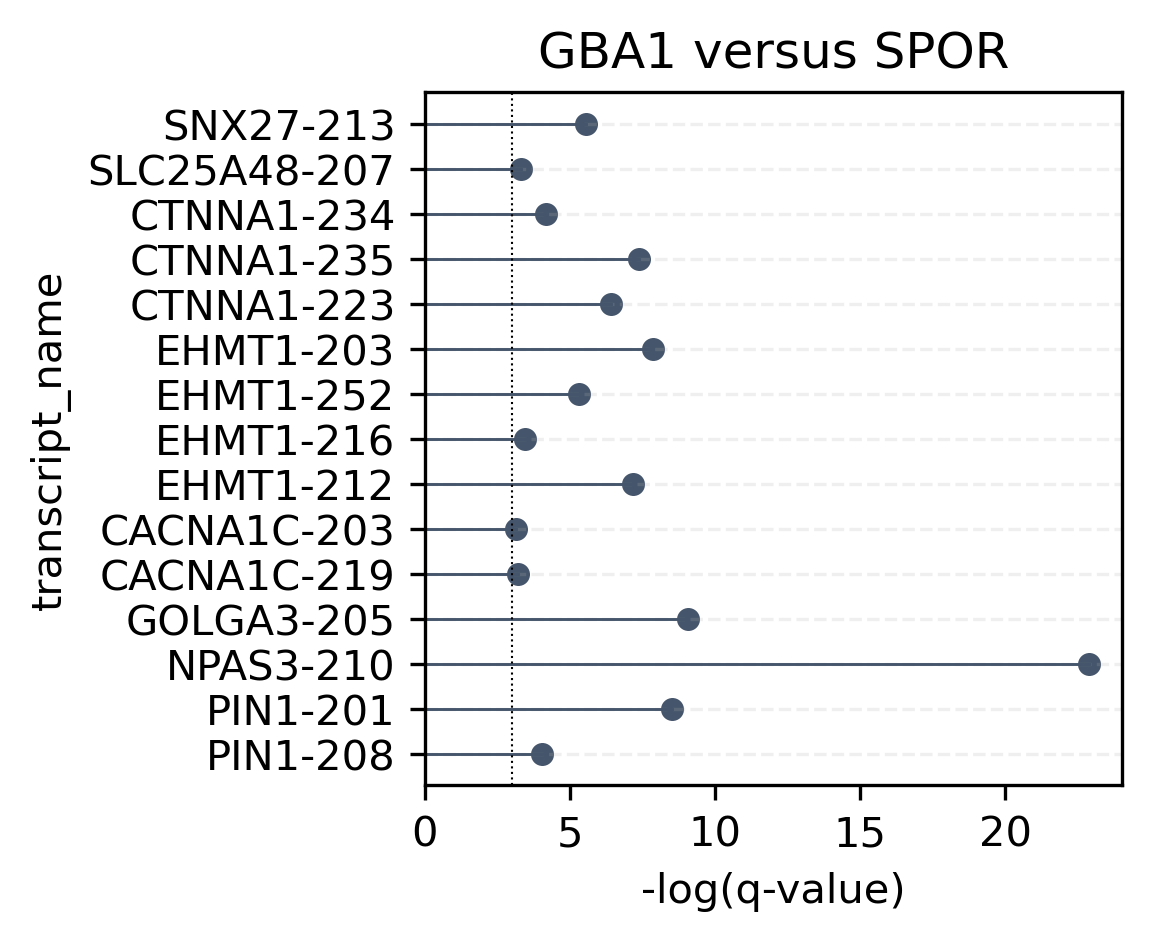

In [13]:
ll = ['FAM230C',
 'NMUR2',
 'SHANK2-AS1',
 'SULT4A1',
 'CACNA1B',
 'SNX27',
 'PIN1',
 'CACNA1C',
 'SLC25A48',
 'CTNNA1',
 'L3MBTL4-AS1',
 'CPM',
 'MYZAP',
 'ATP2B3',
 'EHMT1',
 'GOLGA3',
 'NPAS3']


tmpp = peaks_df[((peaks_df.gene_name.isin(ll)) 
                 & (peaks_df.padj<=0.05) 
                 &(peaks_df.comparison == "SPOR$GBA1"))][
        ["comparison", "padj","log2FoldChange", "transcript_name"]]#.unique().tolist()

y = "transcript_name"
tmpp["-log(q-value)"] = -np.log(tmpp["padj"])
fig, ax = plt.subplots(figsize=(3,3))
sns.scatterplot(data=tmpp,ax=ax, x="-log(q-value)", y=y, color="#45556B")
list_=tmpp[y].tolist()
for i, category in enumerate(list_):
    ax.plot([0, tmpp.iloc[i]["-log(q-value)"]], [i, i], color="#45556B", lw=0.7, zorder=2)

ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.set_xlim(0)
ax.axvline(x=-np.log(0.05), c="k", linestyle=":", linewidth=0.5)
ax.set_title("GBA1 versus SPOR")
plt.savefig("./outdir/Validation_SPOR_GBA1_transcripts.svg", bbox_inches="tight")

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_17325/3090283530.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toplot["size"] = 3


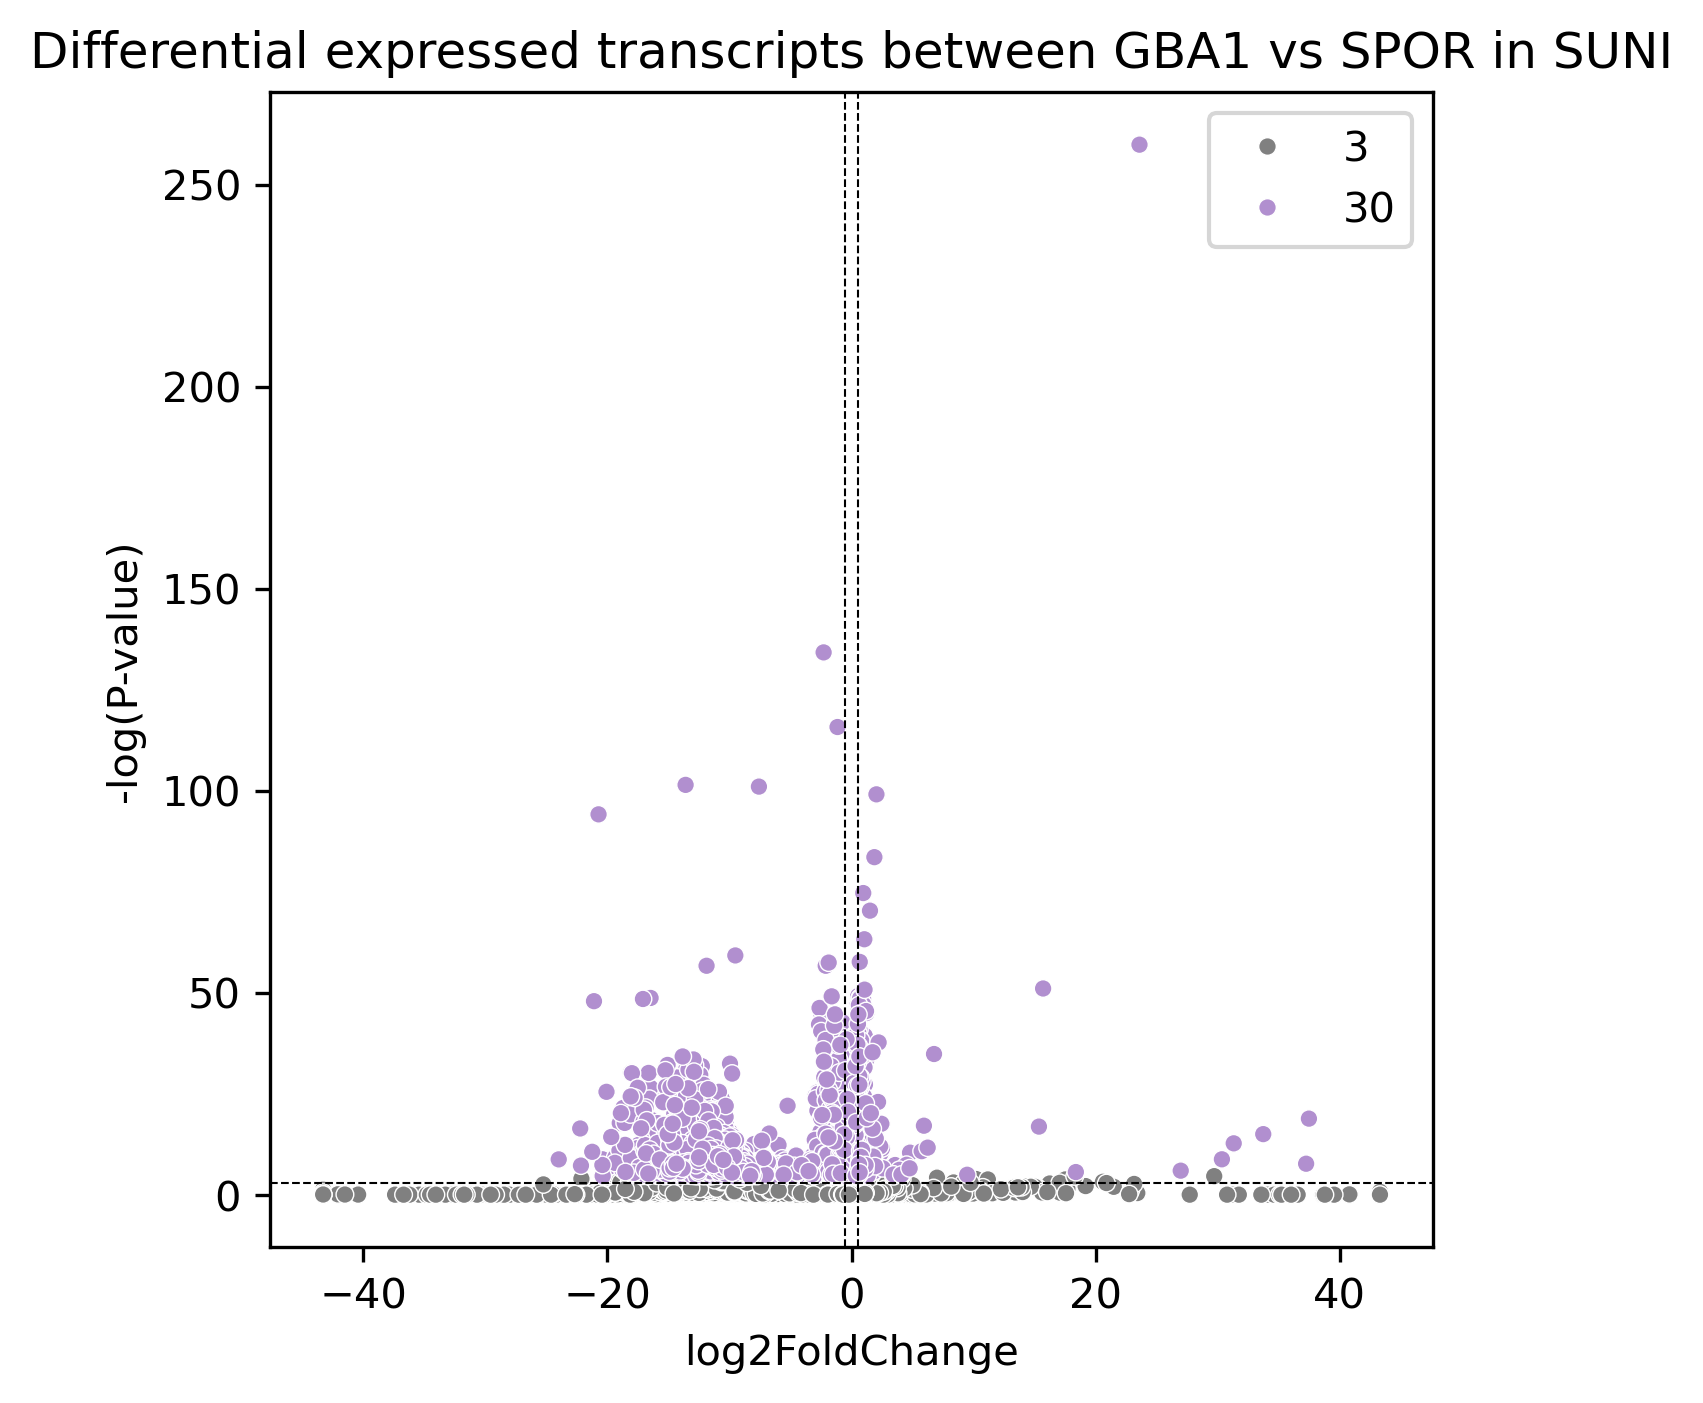

In [10]:
pal = {"3' UTR":"#b18fcf","Promoter":"#42253b", "Intron":"#ffa552","Exon":"#82c0cc","Distal Intergenic":"#82d173"}

peaks_df["-log(P-value)"] = -np.log(peaks_df["padj"])
toplot = peaks_df[(peaks_df.comparison=="SPOR$GBA1")]

fig, ax = plt.subplots(figsize=(5,5))
x="log2FoldChange"
y="-log(P-value)"
toplot["size"] = 3
sns.scatterplot(data = toplot[toplot.padj>0.01], x=x, y=y, color="gray", size=3,)
sns.scatterplot(data = toplot[toplot.padj<=0.01], x=x, y=y, color="#b18fcf", size=30,
               )#palette=pal)
ax.axhline(y=-np.log(0.05), c="k", linestyle="--", linewidth=0.5)
ax.axvline(x=-0.5, c="k", linestyle="--", linewidth=0.5)
ax.axvline(x=0.5, c="k", linestyle="--", linewidth=0.5)
ax.legend(bbox_to_anchor=(1,1))

# texts = []
# for i, it in enumerate(toplot[toplot.padj<=0.05].iterrows()):
#     text = plt.text(it[1][x], it[1][y], it[1]["transcript_name"], fontsize=10)#, color=pal[it[1]["annot"]])
#     texts.append(text)

# # Adjust text to avoid overlap
# adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black'))
# ax.set_xlim(-20, 20)
ax.set_title("Differential expressed transcripts between GBA1 vs SPOR in SUNI")
plt.savefig("outdir/volcano_bulk_DE_blood.svg")
plt.show()

In [56]:
inter2 = [it for it in list(set1) if it in list(set2)]
inter2 += [it for it in list(set1) if it in list(set3)]


res_DE = peaks_df[(peaks_df.comparison=="SPOR$GBA1")]
gene_list = res_DE[(res_DE.padj<=0.05) &(np.abs(res_DE.log2FoldChange)>1)]["gene_name"].str.split(".",expand=True)[0].astype(str).unique().tolist()

# gene_list = adata_pd_bl.var[adata_pd_bl.var.peakid.isin(inter2)]["gene_name"].str.split(".",expand=True)[0].astype(str).unique().tolist()
bg = adata_pd_bl.var.gene_name.str.split(".",expand=True)[0].astype(str).unique().tolist()
enr = gp.enrich(gene_list, # or "./tests/data/gene_list.txt",
                 background=bg,
                 # permutation=10000,
                 # pheno_pos = "SPOR",
        # pheno_neg = "GBA1",
                 gene_sets=['KEGG_2021_Human'],#
                 # gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
                 # organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                )
enr.res2d.sort_values("Odds Ratio", ascending=False)[:20]


,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
181,KEGG_2021_Human,Non-homologous end-joining,NaN,NaN,0,0,7.447653,NaN,DCLRE1C;POLM;PRKDC;LIG4;POLL
178,KEGG_2021_Human,Nicotine addiction,NaN,NaN,0,0,5.747275,NaN,GABRB3;GABRA2;GRIA2;GABRA1;GABRP;CHRNA4;GABRA5...
157,KEGG_2021_Human,Maturity onset diabetes of the young,NaN,NaN,0,0,5.299164,NaN,ONECUT1;SLC2A2;HNF1B;PAX6;HNF1A;MAFA;MNX1;INS
186,KEGG_2021_Human,One carbon pool by folate,NaN,NaN,0,0,5.107638,NaN,MTFMT;MTHFD1L;SHMT2;AMT;MTHFR;FTCD
25,KEGG_2021_Human,Arrhythmogenic right ventricular cardiomyopathy,NaN,NaN,0,0,5.094672,NaN,ITGB1;TCF7L2;JUP;TCF7;CACNA2D3;ATP2A1;CACNA1C;...
209,KEGG_2021_Human,Phenylalanine metabolism,NaN,NaN,0,0,4.964657,NaN,ALDH3A1;ALDH3B2;DDC;GOT1L1;GLYAT
95,KEGG_2021_Human,GABAergic synapse,NaN,NaN,0,0,4.673882,NaN,GABRB3;GLS2;CACNA1A;ADCY1;CACNA1C;SLC6A1;CACNA...
111,KEGG_2021_Human,Glycosylphosphatidylinositol (GPI)-anchor bios...,NaN,NaN,0,0,4.635531,NaN,PIGB;PIGU;PIGT;PIGN;PIGQ;PIGA;PIGK
7,KEGG_2021_Human,African trypanosomiasis,NaN,NaN,0,0,4.587442,NaN,PLCB4;PRKCB;LAMA4;FAS;IL12A;HBA2;HPR;HBA1;PLCB...
125,KEGG_2021_Human,Histidine metabolism,NaN,NaN,0,0,4.468983,NaN,ALDH3A1;ALDH3B2;UROC1;ALDH7A1;ASPA;FTCD


In [50]:
bg

['DDX11L1',
 'WASH7P',
 'MIR6859-1',
 'MIR1302-2HG',
 'MIR1302-2',
 'FAM138A',
 'OR4G4P',
 'OR4G11P',
 'OR4F5',
 'AL627309',
 'CICP27',
 'RNU6-1100P',
 'FO538757',
 'AP006222',
 'RPL23AP24',
 'AL732372',
 'WBP1LP7',
 'OR4F29',
 'CICP7',
 'AL669831',
 'AC114498',
 'MTND1P23',
 'MTND2P28',
 'MTCO1P12',
 'MIR6723',
 'MTCO2P12',
 'MTATP8P1',
 'MTATP6P1',
 'MTCO3P12',
 'WBP1LP6',
 'CICP3',
 'RNU6-1199P',
 'FAM87B',
 'LINC01128',
 'LINC00115',
 'FAM41C',
 'TUBB8P11',
 'AL645608',
 'LINC02593',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'PERM1',
 'HES4',
 'ISG15',
 'AGRN',
 'AL390719',
 'RNF223',
 'C1orf159',
 'LINC01342',
 'MIR200B',
 'MIR200A',
 'MIR429',
 'TTLL10-AS1',
 'TTLL10',
 'TNFRSF18',
 'TNFRSF4',
 'SDF4',
 'B3GALT6',
 'C1QTNF12',
 'AL162741',
 'UBE2J2',
 'LINC01786',
 'SCNN1D',
 'ACAP3',
 'MIR6726',
 'PUSL1',
 'INTS11',
 'MIR6727',
 'AL139287',
 'CPTP',
 'TAS1R3',
 'DVL1',
 'MIR6808',
 'MXRA8',
 'AURKAIP1',
 'NDUFB4P8',
 'CCNL2',
 'AL391244',
 'MRPL20',
 'RN7SL657P',
 'ANKRD65',


In [33]:
term = enr.res2d.copy()
term.Term = term.Term.str.replace("KEGG_2021_Human__","")
ax = gp.dotplot(term,
             # column="-log(Qvalue)",
                column="Odds Ratio",
             title='Pathway Analysis (SUNI)',
             cmap=plt.cm.viridis,
              top_term=20,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)

Error in callback <function _draw_all_if_interactive at 0x30af78cc0> (for post_execute), with arguments args (),kwargs {}:


ConversionError: Failed to convert value(s) to axis units: masked_array(data=[--, --, --, --, --, --, --, --, --, --, --, --, --, --,
                   --, --, --, --, --, --],
             mask=[ True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True],
       fill_value=1e+20,
            dtype=float64)

ConversionError: Failed to convert value(s) to axis units: masked_array(data=[--, --, --, --, --, --, --, --, --, --, --, --, --, --,
                   --, --, --, --, --, --],
             mask=[ True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True],
       fill_value=1e+20,
            dtype=float64)

<Figure size 1200x1800 with 2 Axes>

In [ ]:

res_DE["SYMBOL"] = res_DE["gene_name"].str.split(".",expand=True)[0]
gene_list = res_DE[(res_DE.comparison=="SPOR$GBA1")].set_index("SYMBOL")[["log2FoldChange"]].sort_values("log2FoldChange",ascending=False)

enr = gp.prerank(rnk=gene_list, # or "./tests/data/gene_list.txt",
                 background=bg,
                 permutation_num=1000,
                 gene_sets=['KEGG_2021_Human'],#
                pheno_pos = "SPOR",
                pheno_neg = "GBA1",
                 # gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                )
